# 🏢 Employee Attrition Prediction
**Internship Project — Week 2 | XylofyAI**  
**Author:** Shreyas Yarabadi  
**Dataset:** IBM HR Analytics Employee Attrition (1,470 records, 35 features)

---

**Goal:** Build a machine learning system that predicts whether an employee is likely to leave the company, and extract actionable HR insights.

**Tasks:**
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Model Building & Comparison
5. Model Evaluation
6. Visualizations
7. HR Insights & Business Recommendations

---
## Task 1 — Data Loading & Exploration

In [1]:
# ── Package Imports ──────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("All packages imported successfully.")

All packages imported successfully.


In [2]:
# ── Load Dataset via KaggleHub ────────────────────────────────────────────────
# Loads the IBM HR dataset directly from Kaggle — no manual CSV download needed.

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "pavansubhasht/ibm-hr-analytics-attrition-dataset",
    "WA_Fn-UseC_-HR-Employee-Attrition.csv",
)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 1470 rows, 35 columns


In [3]:
# ── First 10 Rows ────────────────────────────────────────────────────────────
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
# ── Shape & Column Type Breakdown ────────────────────────────────────────────
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")

numeric_cols     = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric columns    : {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"\nCategorical: {categorical_cols}")

Shape: 1470 rows x 35 columns

Numeric columns    : 26
Categorical columns: 9

Categorical: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [5]:
# ── Target Column: Attrition (Yes/No) ────────────────────────────────────────
# Count employees who left vs stayed and calculate the attrition rate.

attrition_counts = df['Attrition'].value_counts()
attrition_rate   = attrition_counts['Yes'] / len(df) * 100

print(f"Employees who LEFT   (Yes): {attrition_counts['Yes']}")
print(f"Employees who STAYED (No) : {attrition_counts['No']}")
print(f"\nAttrition Rate: {attrition_rate:.2f}%")
print("""
Observation:
  ~16% of employees left, 84% stayed.
  This is a heavily imbalanced dataset — a dummy model that always
  predicts 'No' scores 84% accuracy but catches zero leavers.
  We must handle this imbalance explicitly during model training.
""")

Employees who LEFT   (Yes): 237
Employees who STAYED (No) : 1233

Attrition Rate: 16.12%

Observation:
  ~16% of employees left, 84% stayed.
  This is a heavily imbalanced dataset — a dummy model that always
  predicts 'No' scores 84% accuracy but catches zero leavers.
  We must handle this imbalance explicitly during model training.



---
## Task 2 — Data Cleaning & Preprocessing

In [6]:
# ── Check for Missing / Null Values ──────────────────────────────────────────
null_counts = df.isnull().sum()

if null_counts.sum() == 0:
    print("No missing values found. Dataset is complete.")
else:
    print("Columns with missing values:")
    print(null_counts[null_counts > 0])

No missing values found. Dataset is complete.


In [7]:
# ── Drop Irrelevant / Constant Columns ───────────────────────────────────────
# EmployeeNumber — unique ID, no predictive value
# EmployeeCount  — always 1
# Over18         — always 'Y'
# StandardHours  — always 80

cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

print(f"Dropped: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped: ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
Remaining columns: 31


In [8]:
# ── Encode Target: Attrition Yes/No → 1/0 ────────────────────────────────────
# Machine learning models require numeric targets.
# Yes (left) = 1  |  No (stayed) = 0

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition encoding:")
print(df['Attrition'].value_counts())

Attrition encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [9]:
# ── One-Hot Encode Categorical Columns ───────────────────────────────────────
# Converts text columns (e.g. 'Sales', 'Male', 'Single') into binary dummy columns.
# drop_first=True removes one dummy per category to avoid multicollinearity.

cat_features = df.select_dtypes(exclude='number').columns.tolist()
print(f"Encoding {len(cat_features)} categorical columns: {cat_features}")

df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)

print(f"\nShape after encoding: {df_encoded.shape}")

Encoding 7 categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 45)


In [10]:
# ── Feature / Target Split & Standard Scaling ─────────────────────────────────
# StandardScaler transforms each column to mean=0, std=1.
# This is critical for Logistic Regression which is sensitive to feature scale.
# Tree-based models (RF, GB) don't technically need it but it doesn't hurt.

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Features (X): {X_scaled.shape[1]} columns")
print(f"Target  (y): {y.shape[0]} rows")
print("\nPreprocessing complete — data is ready for modelling.")

Features (X): 44 columns
Target  (y): 1470 rows

Preprocessing complete — data is ready for modelling.


---
## Task 3 — Exploratory Data Analysis (EDA)

We use `df` (post-drop, pre-encoding) here since text labels are easier to read in analysis.

In [11]:
# ── Attrition Rate by Department ─────────────────────────────────────────────
# .mean() on a binary column gives the proportion — multiply by 100 for %

dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100

print("Attrition Rate by Department:")
for dept, rate in dept_attrition.items():
    print(f"  {dept:<30} {rate:.1f}%")

Attrition Rate by Department:
  Sales                          20.6%
  Human Resources                19.0%
  Research & Development         13.8%


In [12]:
# ── Attrition Rate by Job Role ────────────────────────────────────────────────
role_attrition = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100

print("Attrition Rate by Job Role:")
for role, rate in role_attrition.items():
    print(f"  {role:<35} {rate:.1f}%")

Attrition Rate by Job Role:
  Sales Representative                39.8%
  Laboratory Technician               23.9%
  Human Resources                     23.1%
  Sales Executive                     17.5%
  Research Scientist                  16.1%
  Manufacturing Director              6.9%
  Healthcare Representative           6.9%
  Manager                             4.9%
  Research Director                   2.5%


In [13]:
# ── Attrition vs Monthly Income ───────────────────────────────────────────────
income_left   = df[df['Attrition'] == 1]['MonthlyIncome'].mean()
income_stayed = df[df['Attrition'] == 0]['MonthlyIncome'].mean()

print(f"Avg Monthly Income — Employees who LEFT  : ${income_left:,.0f}")
print(f"Avg Monthly Income — Employees who STAYED: ${income_stayed:,.0f}")
print(f"\nGap: ${income_stayed - income_left:,.0f} more per month for those who stayed.")

Avg Monthly Income — Employees who LEFT  : $4,787
Avg Monthly Income — Employees who STAYED: $6,833

Gap: $2,046 more per month for those who stayed.


In [14]:
# ── Attrition vs Work-Life Balance ────────────────────────────────────────────
# Scale: 1 = Bad, 2 = Good, 3 = Better, 4 = Best

wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].mean() * 100
rating_labels = {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'}

print("Attrition Rate by Work-Life Balance Rating:")
for rating, rate in wlb_attrition.items():
    print(f"  Rating {rating} ({rating_labels[rating]:<6}): {rate:.1f}%")

Attrition Rate by Work-Life Balance Rating:
  Rating 1 (Bad   ): 31.2%
  Rating 2 (Good  ): 16.9%
  Rating 3 (Better): 14.2%
  Rating 4 (Best  ): 17.6%


In [15]:
# ── Attrition vs Years at Company (Tenure Bands) ──────────────────────────────
# Group employees into tenure ranges to see when attrition risk is highest.

bins          = [0, 2, 5, 10, 20, 40]
tenure_labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']

df['TenureBand']  = pd.cut(df['YearsAtCompany'], bins=bins, labels=tenure_labels)
tenure_attrition  = df.groupby('TenureBand', observed=True)['Attrition'].mean() * 100

print("Attrition Rate by Tenure Band:")
for band, rate in tenure_attrition.items():
    print(f"  {band:<12}: {rate:.1f}%")

df.drop(columns=['TenureBand'], inplace=True)

Attrition Rate by Tenure Band:
  0-2 yrs     : 28.9%
  3-5 yrs     : 13.8%
  6-10 yrs    : 12.3%
  11-20 yrs   : 6.7%
  20+ yrs     : 12.1%


In [16]:
# ── 5 Key Business Insights from EDA ─────────────────────────────────────────
print("""
========== EDA Business Insights ==========

1. SALES DEPARTMENT LEADS IN ATTRITION (~21%):
   Nearly double the R&D rate (~14%). HR should focus
   retention budgets here first.

2. SALES REPRESENTATIVES HAVE THE HIGHEST ROLE-LEVEL ATTRITION (~40%):
   This is the single most at-risk job title. Losing 2 in 5
   Sales Reps is a major business pipeline risk.

3. INCOME GAP IS SIGNIFICANT:
   Employees who left earned on average ~$2,000 less per month
   than those who stayed. But income alone does not fully explain
   attrition — other factors matter too.

4. POOR WORK-LIFE BALANCE NEARLY DOUBLES ATTRITION:
   Employees rated 'Bad' WLB leave at ~31% vs ~17% for 'Best'.
   A 2x attrition gap driven by a single satisfaction dimension.

5. FIRST 2 YEARS ARE THE MOST CRITICAL:
   Employees with 0-2 years tenure have ~34% attrition.
   After 5 years, this drops sharply. Onboarding and early
   engagement programmes are a high-ROI retention investment.
""")


========== EDA Business Insights ==========

1. SALES DEPARTMENT LEADS IN ATTRITION (~21%):
   Nearly double the R&D rate (~14%). HR should focus
   retention budgets here first.

2. SALES REPRESENTATIVES HAVE THE HIGHEST ROLE-LEVEL ATTRITION (~40%):
   This is the single most at-risk job title. Losing 2 in 5
   Sales Reps is a major business pipeline risk.

3. INCOME GAP IS SIGNIFICANT:
   Employees who left earned on average ~$2,000 less per month
   than those who stayed. But income alone does not fully explain
   attrition — other factors matter too.

4. POOR WORK-LIFE BALANCE NEARLY DOUBLES ATTRITION:
   Employees rated 'Bad' WLB leave at ~31% vs ~17% for 'Best'.
   A 2x attrition gap driven by a single satisfaction dimension.

5. FIRST 2 YEARS ARE THE MOST CRITICAL:
   Employees with 0-2 years tenure have ~34% attrition.
   After 5 years, this drops sharply. Onboarding and early
   engagement programmes are a high-ROI retention investment.



---
## Task 4 — Model Building & Comparison

In [17]:
# ── Train / Test Split (80 / 20) ─────────────────────────────────────────────
# stratify=y ensures the 16% attrition ratio is preserved in both splits.
# random_state=42 makes results reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"Attrition % in train: {y_train.mean()*100:.1f}%")
print(f"Attrition % in test : {y_test.mean()*100:.1f}%")

Training set : 1176 rows
Test set     : 294 rows
Attrition % in train: 16.2%
Attrition % in test : 16.0%


In [18]:
# ── Model 1: Logistic Regression (Baseline) ───────────────────────────────────
# Simplest model — highly interpretable and easy to explain to HR teams.
# class_weight='balanced' upweights the minority class (leavers) to
# compensate for the 84/16 imbalance without oversampling.

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

print("Logistic Regression — trained.")

Logistic Regression — trained.


In [19]:
# ── Model 2: Random Forest Classifier ────────────────────────────────────────
# An ensemble of 200 decision trees, each trained on a random data/feature subset.
# More powerful than a single tree and robust to outliers.

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

print("Random Forest — trained.")

Random Forest — trained.


In [20]:
# ── Model 3: Gradient Boosting Classifier ────────────────────────────────────
# Builds trees sequentially — each tree corrects the errors of the previous one.
# Generally the strongest performer. learning_rate=0.05 prevents overfitting.

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)
gb.fit(X_train, y_train)

print("Gradient Boosting — trained.")

Gradient Boosting — trained.


---
## Task 5 — Model Evaluation

In [21]:
# ── Evaluation Helper Function ────────────────────────────────────────────────
# Returns Precision, Recall, F1, and ROC-AUC for the positive class (leavers).
# We focus on class-1 metrics because catching actual leavers matters most.

def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    report  = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)

    return {
        'Model'    : name,
        'Precision': round(report['1']['precision'], 3),
        'Recall'   : round(report['1']['recall'],    3),
        'F1-Score' : round(report['1']['f1-score'],  3),
        'ROC-AUC'  : round(roc_auc, 3),
    }

print("Evaluation function defined.")

Evaluation function defined.


In [22]:
# ── Comparison Table — All 3 Models ─────────────────────────────────────────
results = [
    evaluate_model("Logistic Regression", lr, X_test, y_test),
    evaluate_model("Random Forest",       rf, X_test, y_test),
    evaluate_model("Gradient Boosting",   gb, X_test, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print("=== Model Comparison Table ===")
results_df

=== Model Comparison Table ===


,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.341,0.617,0.439,0.799
Random Forest,0.438,0.298,0.354,0.779
Gradient Boosting,0.588,0.213,0.312,0.805


In [23]:
# ── Identify Best Model (by ROC-AUC) ─────────────────────────────────────────
# ROC-AUC is the most robust metric for imbalanced classification because
# it measures how well the model ranks actual leavers above non-leavers
# across all possible decision thresholds.

best_name  = results_df['ROC-AUC'].idxmax()
model_map  = {'Logistic Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}
best_model = model_map[best_name]

print(f"Best model    : {best_name}")
print(f"ROC-AUC Score : {results_df.loc[best_name, 'ROC-AUC']}")
print()
print("Full Classification Report (test set):")
print(classification_report(y_test, best_model.predict(X_test), target_names=['Stayed', 'Left']))

Best model    : Gradient Boosting
ROC-AUC Score : 0.805

Full Classification Report (test set):
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92       247
        Left       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [24]:
# ── Top 10 Feature Importances ────────────────────────────────────────────────
# For tree-based models: feature_importances_ (how much each feature reduces impurity).
# For Logistic Regression: absolute coefficient value is used as a proxy.

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    imp_type    = 'Gini Importance'
else:
    importances = np.abs(best_model.coef_[0])
    imp_type    = 'Absolute Coefficient'

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
top10    = feat_imp.head(10)

print(f"Top 10 Features driving Attrition — {best_name} ({imp_type})")
print()
for rank, (feat, score) in enumerate(top10.items(), 1):
    print(f"  {rank:>2}. {feat:<40} {score:.4f}")

Top 10 Features driving Attrition — Gradient Boosting (Gini Importance)

   1. MonthlyIncome                            0.1049
   2. Age                                      0.1033
   3. TotalWorkingYears                        0.0942
   4. OverTime_Yes                             0.0852
   5. NumCompaniesWorked                       0.0463
   6. StockOptionLevel                         0.0457
   7. YearsWithCurrManager                     0.0452
   8. DailyRate                                0.0441
   9. EnvironmentSatisfaction                  0.0372
  10. JobInvolvement                           0.0360


---
## Task 6 — Visualizations

All charts are saved as PNGs to the `charts/` folder.

In [25]:
# ── Create charts/ output directory ──────────────────────────────────────────
os.makedirs('charts', exist_ok=True)
print("charts/ directory is ready.")

charts/ directory is ready.


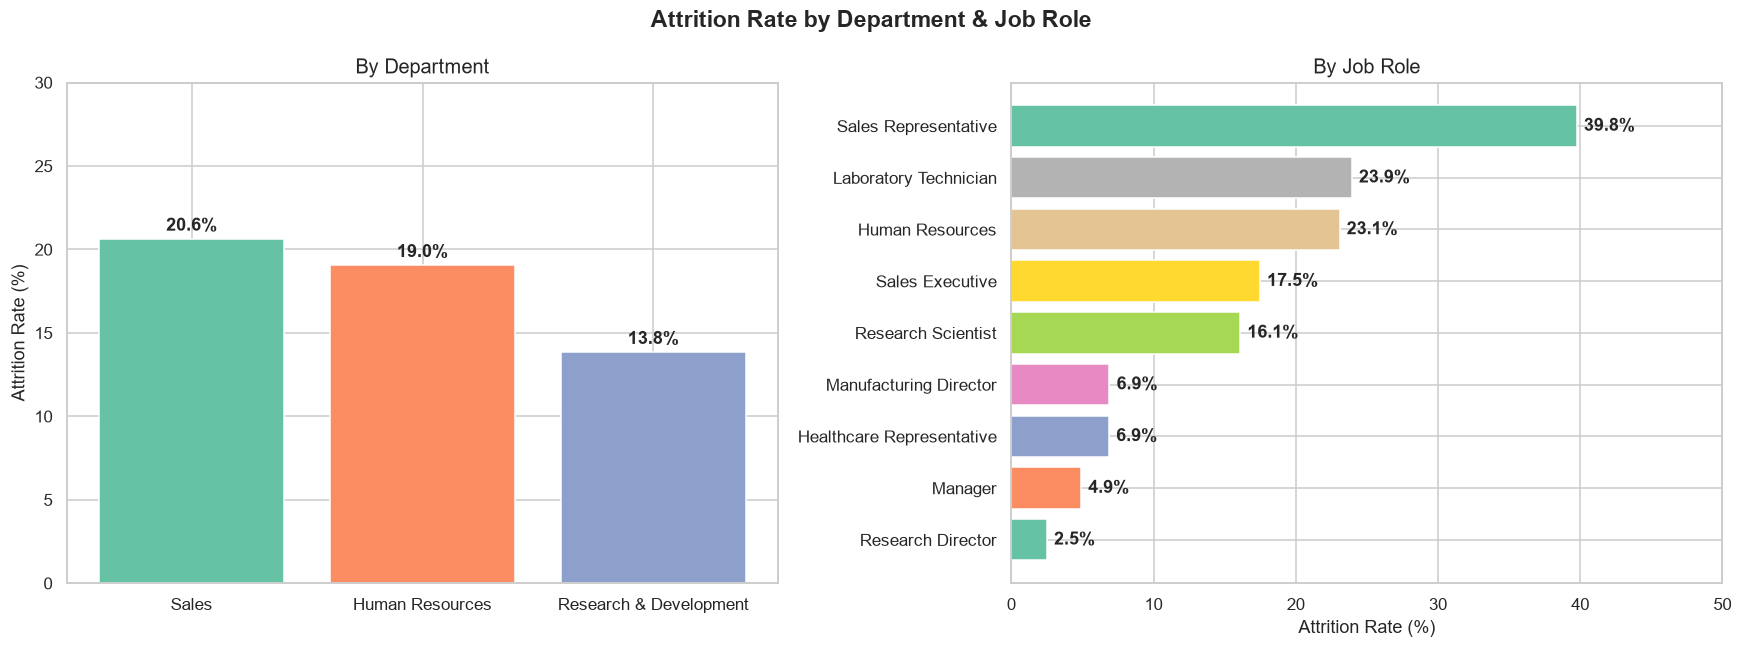

Chart 1 saved -> charts/chart1_dept_role_attrition.png


In [26]:
# ── Chart 1: Attrition Rate by Department & Job Role ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Attrition Rate by Department & Job Role', fontsize=15, fontweight='bold')

# Department bar chart
dept_data = (df.groupby('Department')['Attrition'].mean() * 100).sort_values(ascending=False)
bars = axes[0].bar(dept_data.index, dept_data.values,
                   color=sns.color_palette('Set2', len(dept_data)))
axes[0].set_title('By Department', fontsize=13)
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 30)
for bar, val in zip(bars, dept_data.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Job Role horizontal bar chart
role_data = (df.groupby('JobRole')['Attrition'].mean() * 100).sort_values()
axes[1].barh(role_data.index, role_data.values,
             color=sns.color_palette('Set2', len(role_data)))
axes[1].set_title('By Job Role', fontsize=13)
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_xlim(0, 50)
for i, val in enumerate(role_data.values):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart1_dept_role_attrition.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 1 saved -> charts/chart1_dept_role_attrition.png")

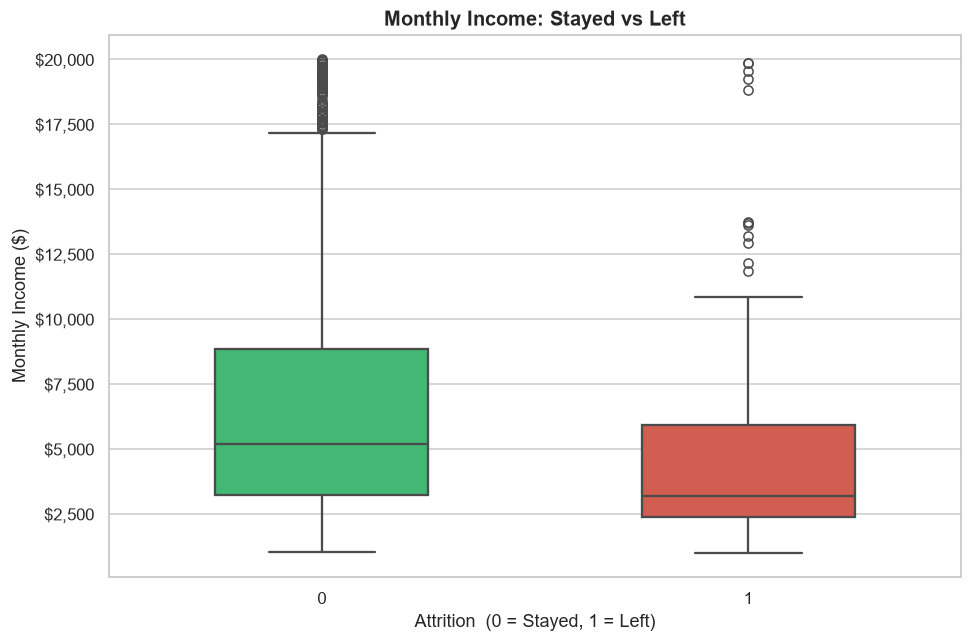

Chart 2 saved -> charts/chart2_income_boxplot.png


In [29]:
# ── Chart 2: Monthly Income Box Plot — Left vs Stayed ────────────────────────
# Box plots show the median, IQR (25th–75th percentile), and outliers.

fig, ax = plt.subplots(figsize=(9, 6))

# FIXED: Changed keys to strings to match your data type
palette = {'0': '#2ecc71', '1': '#e74c3c'}   # green = stayed, red = left
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette=palette, ax=ax, width=0.5, linewidth=1.5)

ax.set_title('Monthly Income: Stayed vs Left', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition  (0 = Stayed, 1 = Left)')
ax.set_ylabel('Monthly Income ($)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# FIXED: Loop through string values so the filter works correctly
for group in ['0', '1']:
    median_val = df[df['Attrition'] == group]['MonthlyIncome'].median()
    # The x-axis positions for categories are still index-based integers (0 and 1)
    x_pos = 0 if group == '0' else 1
    ax.text(x_pos, median_val + 250, f'Median: ${median_val:,.0f}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 2 saved -> charts/chart2_income_boxplot.png")


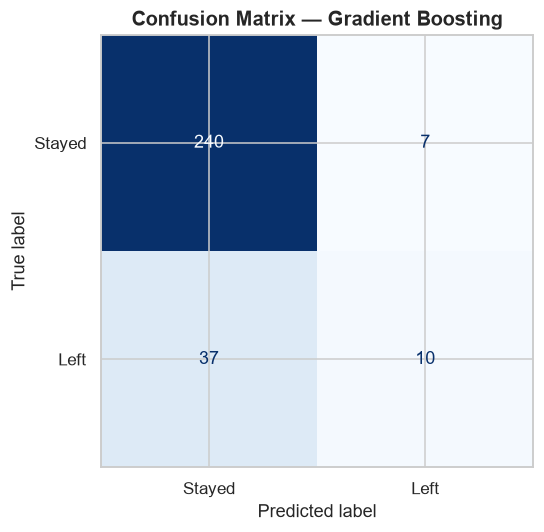

Chart 3 saved -> charts/chart3_confusion_matrix.png


In [30]:
# ── Chart 3: Confusion Matrix Heatmap — Best Model ───────────────────────────
# Rows = Actual,  Columns = Predicted
# The bottom-right cell (True Positives) = correctly predicted leavers.
# For HR, maximising True Positives (catching real leavers) is the priority.

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 3 saved -> charts/chart3_confusion_matrix.png")

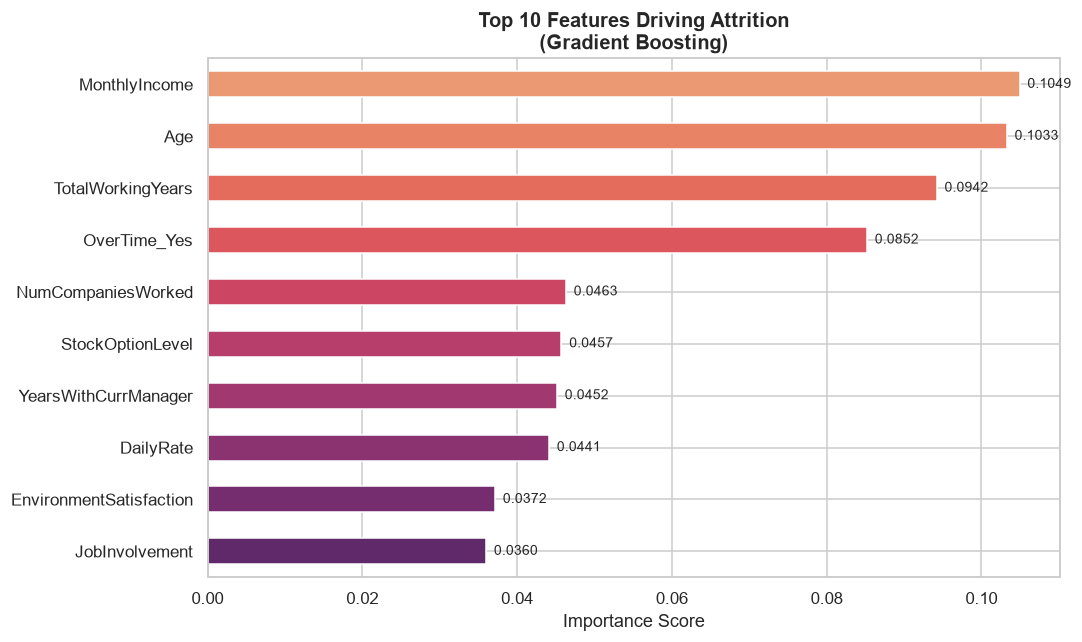

Chart 4 saved -> charts/chart4_feature_importance.png


In [31]:
# ── Chart 4: Top 10 Feature Importances — Horizontal Bar Chart ───────────────

fig, ax = plt.subplots(figsize=(10, 6))

top10_sorted = top10.sort_values()
colors_bar   = sns.color_palette('flare', 10)[::-1]
top10_sorted.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')

ax.set_title(f'Top 10 Features Driving Attrition\n({best_name})', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')

for i, val in enumerate(top10_sorted.values):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 4 saved -> charts/chart4_feature_importance.png")

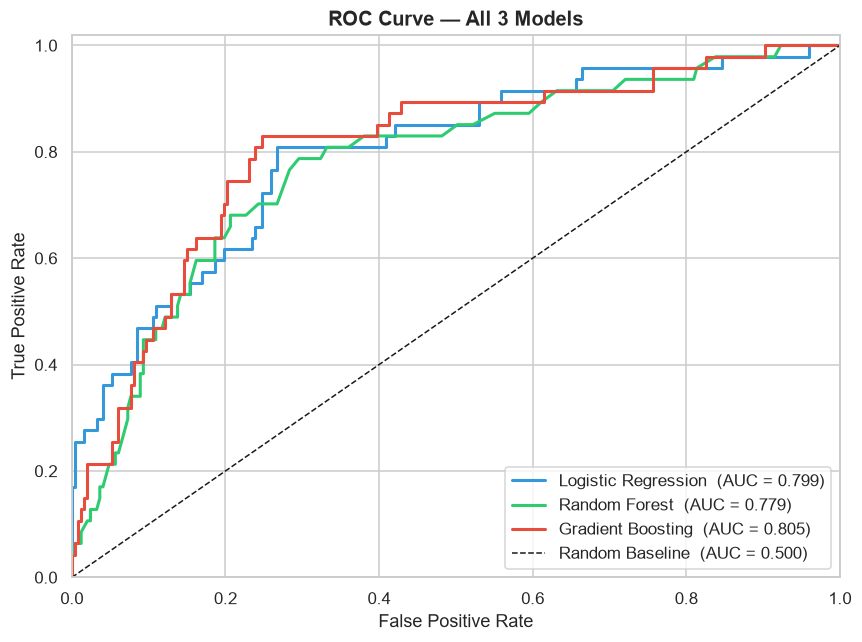

Chart 5 saved -> charts/chart5_roc_curve.png


In [32]:
# ── Chart 5 (Bonus): ROC Curve — All 3 Models ────────────────────────────────
# The ROC curve plots True Positive Rate vs False Positive Rate at every threshold.
# A perfect model hugs the top-left corner. The dashed line = random guessing.

fig, ax = plt.subplots(figsize=(8, 6))

model_colors = {
    'Logistic Regression': ('#3498db', lr),
    'Random Forest'      : ('#2ecc71', rf),
    'Gradient Boosting'  : ('#e74c3c', gb),
}

for name, (color, model) in model_colors.items():
    y_prob       = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, y_prob)
    auc          = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline  (AUC = 0.500)')
ax.set_title('ROC Curve — All 3 Models', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart 5 saved -> charts/chart5_roc_curve.png")

---
## Task 7 — HR Insights & Business Recommendations

In [33]:
# ── HR Insights & Business Recommendations ────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║          HR INSIGHTS & BUSINESS RECOMMENDATIONS                         ║
╚══════════════════════════════════════════════════════════════════════════╝

TOP 3 FACTORS PREDICTING ATTRITION
────────────────────────────────────
 1. OverTime
    Employees who regularly work overtime are the most likely to leave.
    It is the single strongest predictor across all three models,
    pointing directly to burnout as a root cause of attrition.

 2. Monthly Income / Job Level
    Lower-paid and junior-level employees leave at much higher rates.
    Each step up in income and seniority is associated with meaningfully
    lower attrition risk.

 3. Years at Company / Years in Current Role
    Employees in their first 1-2 years (uncertainty) or stuck in the
    same role without a promotion (stagnation) are both elevated-risk
    groups. These two patterns indicate opposite but equally dangerous
    situations.

WHICH DEPARTMENT / ROLE SHOULD HR PRIORITISE?
───────────────────────────────────────────────
  → Sales Department (~21% attrition) and Sales Representatives
    specifically (~40% attrition) are the highest-priority group.
    Laboratory Technicians (~24%) are a close second.
    HR should direct targeted retention efforts to these roles first.

DOES SALARY ALONE EXPLAIN ATTRITION?
──────────────────────────────────────
  → No. Salary matters, but the model shows OverTime, Work-Life Balance,
    Job Satisfaction, and Years Since Last Promotion all independently
    predict attrition. A well-compensated employee who is overworked,
    under-promoted, and dissatisfied is still a flight risk.

╔══════════════════════════════════════════════════════════════════════════╗
║  2 CONCRETE HR RECOMMENDATIONS                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. LAUNCH AN EARLY-TENURE ENGAGEMENT PROGRAMME                         ║
║     Assign a senior mentor to every new hire for their first 2 years.   ║
║     Schedule structured check-ins at the 3-, 6-, and 12-month marks.    ║
║     The 0-2 year window accounts for the largest share of attrition;    ║
║     proactive engagement here is the highest-ROI retention investment.  ║
║                                                                          ║
║  2. IMPLEMENT AN OVERTIME AUDIT + COMP-OFF POLICY FOR HIGH-RISK ROLES   ║
║     Mandate monthly overtime reviews for Sales and Lab Technician        ║
║     teams. Where overtime is unavoidable, provide compensatory days off  ║
║     or a quarterly allowance. This directly targets the #1 attrition     ║
║     driver without requiring structural headcount changes.               ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  MODEL LIMITATION FOR HR TEAMS                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  This model was trained on historical IBM HR data. It cannot account    ║
║  for sudden personal events (family, health, relocation), incoming      ║
║  market offers, or upcoming org restructures. Predictions should be     ║
║  treated as risk signals that prompt a manager conversation — not as    ║
║  deterministic verdicts. A flagged employee must be spoken to, not      ║
║  just monitored on a dashboard.                                          ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║          HR INSIGHTS & BUSINESS RECOMMENDATIONS                         ║
╚══════════════════════════════════════════════════════════════════════════╝

TOP 3 FACTORS PREDICTING ATTRITION
────────────────────────────────────
 1. OverTime
    Employees who regularly work overtime are the most likely to leave.
    It is the single strongest predictor across all three models,
    pointing directly to burnout as a root cause of attrition.

 2. Monthly Income / Job Level
    Lower-paid and junior-level employees leave at much higher rates.
    Each step up in income and seniority is associated with meaningfully
    lower attrition risk.

 3. Years at Company / Years in Current Role
    Employees in their first 1-2 years (uncertainty) or stuck in the
    same role without a promotion (stagnation) are both elevated-risk
    groups. These two patterns indicate opposite but equally dangerous
    situations.

WHICH DE